# Retailer Quality Analysis
Instacart-inspired fulfillment quality and retailer performance analysis.

In [16]:
import pandas as pd

orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date", "promised_delivery_time", "actual_delivery_time"])
retailers = pd.read_csv("../data/retailers.csv", parse_dates=["launch_date"])
escalations = pd.read_csv("../data/escalations.csv", parse_dates=["created_at", "resolved_at"])

orders.head()

,order_id,retailer_id,order_date,promised_delivery_time,actual_delivery_time,status,order_value
0,O001,001,2026-09-01 09:15:00,2026-09-02 10:00:00,2026-09-02 09:48:00,completed,45.99
1,O002,001,2026-09-01 11:20:00,2026-09-02 12:00:00,2026-09-02 12:15:00,completed,32.50
2,O003,001,2026-09-03 08:40:00,2026-09-04 09:00:00,NaT,cancelled,0.00
3,O004,001,2026-09-04 10:05:00,2026-09-05 10:00:00,2026-09-05 10:07:00,completed,27.80
4,O005,001,2026-09-05 13:10:00,2026-09-06 12:00:00,2026-09-06 11:55:00,completed,63.40


## Create Fulfillment Flags

In [17]:
orders["is_cancelled"] = (orders["status"] == "cancelled").astype(int)
orders["is_rescheduled"] = (orders["status"] == "rescheduled").astype(int)
orders["is_completed"] = (orders["status"] == "completed").astype(int)

orders["is_on_time"] = (
    (orders["status"] == "completed") &
    (orders["actual_delivery_time"] <= orders["promised_delivery_time"])
).astype(int)

orders.head()

,order_id,retailer_id,order_date,promised_delivery_time,actual_delivery_time,status,order_value,is_cancelled,is_rescheduled,is_completed,is_on_time
0,O001,001,2026-09-01 09:15:00,2026-09-02 10:00:00,2026-09-02 09:48:00,completed,45.99,0,0,1,1
1,O002,001,2026-09-01 11:20:00,2026-09-02 12:00:00,2026-09-02 12:15:00,completed,32.50,0,0,1,0
2,O003,001,2026-09-03 08:40:00,2026-09-04 09:00:00,NaT,cancelled,0.00,1,0,0,0
3,O004,001,2026-09-04 10:05:00,2026-09-05 10:00:00,2026-09-05 10:07:00,completed,27.80,0,0,1,0
4,O005,001,2026-09-05 13:10:00,2026-09-06 12:00:00,2026-09-06 11:55:00,completed,63.40,0,0,1,1


## Aggregate Retailer Metrics

In [18]:
retailer_metrics = (
    orders
    .groupby("retailer_id")
    .agg(
        total_orders=("order_id", "count"),
        cancelled_orders=("is_cancelled", "sum"),
        rescheduled_orders=("is_rescheduled", "sum"),
        completed_orders=("is_completed", "sum"),
        on_time_orders=("is_on_time", "sum"),
        avg_order_value=("order_value", "mean")
    )
)

retailer_metrics

,total_orders,cancelled_orders,rescheduled_orders,completed_orders,on_time_orders,avg_order_value
retailer_id,,,,,,
001,10,2,0,8,3,32.459
R002,10,2,0,8,1,32.743
R003,10,2,0,8,4,30.805
R004,10,2,0,8,0,36.469
R005,10,2,0,8,2,36.178
R006,10,2,0,8,2,25.078
R007,10,2,0,8,2,35.138
R008,10,2,0,8,4,33.258
R009,10,2,0,8,0,33.338


## Calculate KPI Rates

In [19]:
retailer_metrics["cancellation_rate"] = retailer_metrics["cancelled_orders"] / retailer_metrics["total_orders"]
retailer_metrics["reschedule_rate"] = retailer_metrics["rescheduled_orders"] / retailer_metrics["total_orders"]
retailer_metrics["on_time_rate"] = retailer_metrics["on_time_orders"] / retailer_metrics["completed_orders"]

retailer_metrics

,total_orders,cancelled_orders,rescheduled_orders,completed_orders,on_time_orders,avg_order_value,cancellation_rate,reschedule_rate,on_time_rate
retailer_id,,,,,,,,,
001,10,2,0,8,3,32.459,0.2,0.0,0.375
R002,10,2,0,8,1,32.743,0.2,0.0,0.125
R003,10,2,0,8,4,30.805,0.2,0.0,0.500
R004,10,2,0,8,0,36.469,0.2,0.0,0.000
R005,10,2,0,8,2,36.178,0.2,0.0,0.250
R006,10,2,0,8,2,25.078,0.2,0.0,0.250
R007,10,2,0,8,2,35.138,0.2,0.0,0.250
R008,10,2,0,8,4,33.258,0.2,0.0,0.500
R009,10,2,0,8,0,33.338,0.2,0.0,0.000


## Join Retailer Attributes

In [20]:
retailer_metrics = retailer_metrics.merge(retailers, on="retailer_id", how="left")
retailer_metrics

,retailer_id,total_orders,cancelled_orders,rescheduled_orders,completed_orders,on_time_orders,avg_order_value,cancellation_rate,reschedule_rate,on_time_rate,retailer_name,region,launch_date,tier
0,001,10,2,0,8,3,32.459,0.2,0.0,0.375,FreshMart,East,2025-06-01,strategic
1,R002,10,2,0,8,1,32.743,0.2,0.0,0.125,GreenBasket,West,2024-11-15,core
2,R003,10,2,0,8,4,30.805,0.2,0.0,0.500,UrbanGrocer,Central,2025-02-20,long_tail
3,R004,10,2,0,8,0,36.469,0.2,0.0,0.000,RiverMarket,East,2024-09-10,strategic
4,R005,10,2,0,8,2,36.178,0.2,0.0,0.250,MapleFoods,West,2025-01-25,core
5,R006,10,2,0,8,2,25.078,0.2,0.0,0.250,CityPantry,Central,2024-03-18,long_tail
6,R007,10,2,0,8,2,35.138,0.2,0.0,0.250,DailyHarvest,East,2025-04-05,strategic
7,R008,10,2,0,8,4,33.258,0.2,0.0,0.500,NorthGrocer,West,2023-12-12,core
8,R009,10,2,0,8,0,33.338,0.2,0.0,0.000,HomeBasket,Central,2024-07-22,long_tail
9,R010,10,2,0,8,2,36.818,0.2,0.0,0.250,PurePantry,East,2025-02-01,strategic


## Add Escalation Metrics

In [21]:
escalation_counts = (
    escalations
    .groupby("retailer_id")
    .agg(escalation_count=("escalation_id", "count"))
)

retailer_metrics = retailer_metrics.merge(escalation_counts, on="retailer_id", how="left").fillna({"escalation_count": 0})
retailer_metrics["escalation_rate"] = retailer_metrics["escalation_count"] / retailer_metrics["total_orders"]

retailer_metrics

,retailer_id,total_orders,cancelled_orders,rescheduled_orders,completed_orders,on_time_orders,avg_order_value,cancellation_rate,reschedule_rate,on_time_rate,retailer_name,region,launch_date,tier,escalation_count,escalation_rate
0,001,10,2,0,8,3,32.459,0.2,0.0,0.375,FreshMart,East,2025-06-01,strategic,2.0,0.2
1,R002,10,2,0,8,1,32.743,0.2,0.0,0.125,GreenBasket,West,2024-11-15,core,1.0,0.1
2,R003,10,2,0,8,4,30.805,0.2,0.0,0.500,UrbanGrocer,Central,2025-02-20,long_tail,1.0,0.1
3,R004,10,2,0,8,0,36.469,0.2,0.0,0.000,RiverMarket,East,2024-09-10,strategic,2.0,0.2
4,R005,10,2,0,8,2,36.178,0.2,0.0,0.250,MapleFoods,West,2025-01-25,core,2.0,0.2
5,R006,10,2,0,8,2,25.078,0.2,0.0,0.250,CityPantry,Central,2024-03-18,long_tail,2.0,0.2
6,R007,10,2,0,8,2,35.138,0.2,0.0,0.250,DailyHarvest,East,2025-04-05,strategic,2.0,0.2
7,R008,10,2,0,8,4,33.258,0.2,0.0,0.500,NorthGrocer,West,2023-12-12,core,1.0,0.1
8,R009,10,2,0,8,0,33.338,0.2,0.0,0.000,HomeBasket,Central,2024-07-22,long_tail,0.0,0.0
9,R010,10,2,0,8,2,36.818,0.2,0.0,0.250,PurePantry,East,2025-02-01,strategic,0.0,0.0


## Save Output

In [22]:
retailer_metrics.to_csv("../outputs/retailer_quality_metrics.csv", index=True)

## Visualizing Retailer Performance

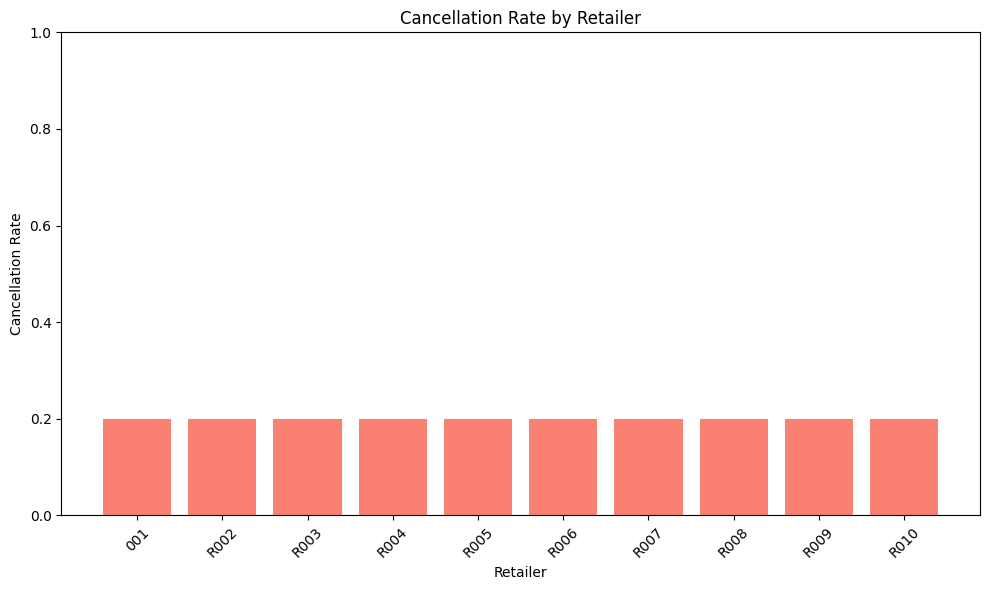

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(retailer_metrics["retailer_id"], retailer_metrics["cancellation_rate"], color="salmon")
plt.title("Cancellation Rate by Retailer")
plt.ylabel("Cancellation Rate")
plt.xlabel("Retailer")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## On-Time Delivery Rate by Retailer

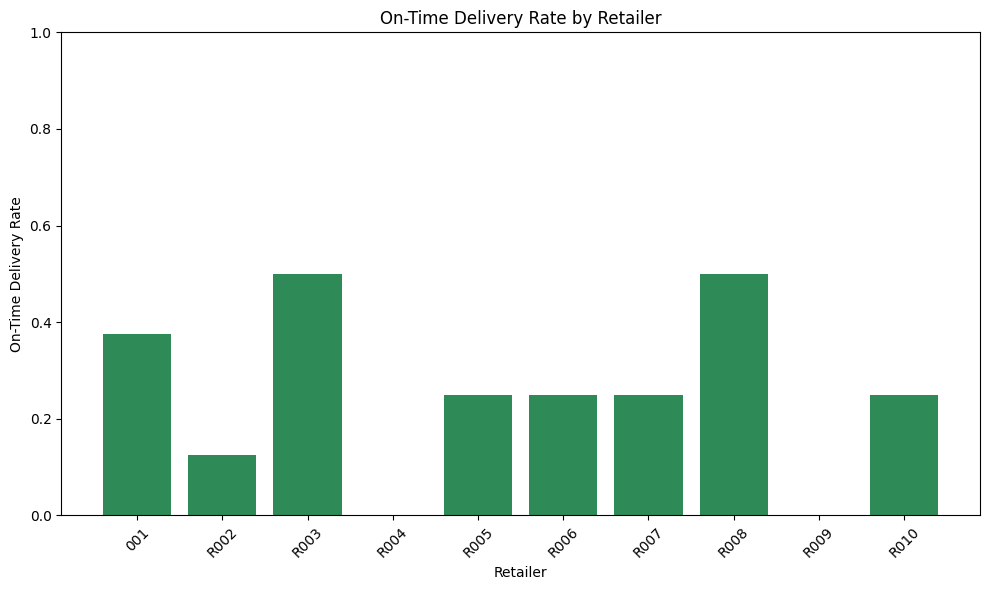

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(retailer_metrics["retailer_id"], retailer_metrics["on_time_rate"], color="seagreen")
plt.title("On-Time Delivery Rate by Retailer")
plt.ylabel("On-Time Delivery Rate")
plt.xlabel("Retailer")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Escalation Rate by Retailer

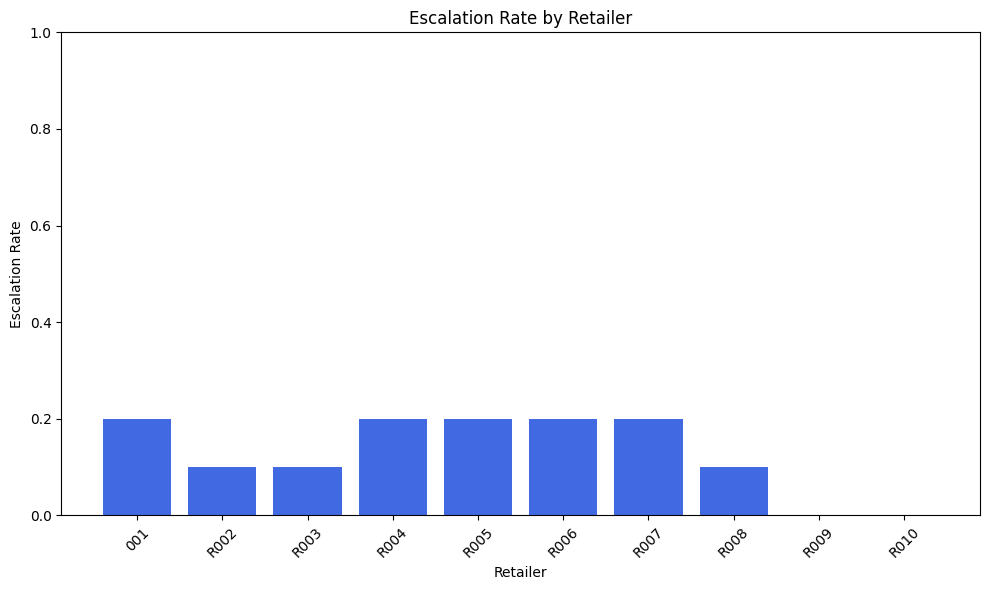

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(retailer_metrics["retailer_id"], retailer_metrics["escalation_rate"], color="royalblue")
plt.title("Escalation Rate by Retailer")
plt.ylabel("Escalation Rate")
plt.xlabel("Retailer")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
